
# TAREA 2

**Fecha:** 2026-09-20  

> Entrega: **un solo notebook** con tus soluciones y gráficas.



## Relación con **Serie 2**

Esta tarea es la **extensión computacional** de la Serie 2.

**Flujo recomendado (por ejercicio):**
1) Resuelve **en papel** (análisis / fórmulas / razonamiento).
2) Implementa aquí para **verificar** con código y gráficas.
3) Si hay contradicción: **debug** hasta entender el error (en el papel o en el código).

**Submission Instructions:**
1) Submit all exercises in a single Google Colab notebook.

2) Show the mathematical operations used to obtain each result.
3) Implement the corresponding calculations in Python.
4) Include all relevant plots and clearly label axes, units, and titles.
5) For correlation exercises, plot correlation as a function of lag.
6) Briefly interpret the result obtained from each graph.
7) Do not use a single library function as a substitute for the requested mathematical procedure unless explicitly indicated.



## Reglas (importantes)

- Puedes usar ChatGPT (u otra IA) **solo como verificador**.
- Tu notebook debe incluir tu razonamiento (comentarios) y tu código.
- **No uses atajos** que oculten la idea:
  - `np.roll`, `np.flip`, `x[::-1]` (para inversión), `np.convolve`, `np.correlate`
- Sí puedes usar NumPy básico, `for` loops, y operaciones elementales.

**Pista:** Si tu solución cabe en 1 línea usando una función “mágica”, probablemente no cuenta.


**Clave:** La IA NO sustituye el papel. Úsala para *verificar* y para detectar errores, igual que usarías una calculadora.



## 1) Datos del estudiante

Completa esta celda y vuelve a correrla.


In [ ]:

# === Datos de los estudiantes ===
NOMBRE1 = "Dominguez Calihua Fernando"
NOMBRE2= "Chirino Sanchez Luis Fernando"
NOMBRE3= "Garay Hernández Jorge Efrén"
GRUPO = "4"

print("Nombre 1:", NOMBRE2)
print("Nombre 2:", NOMBRE1)
print("Nombre 3:", NOMBRE3)
print("Grupo:", GRUPO)


Nombre 1: Chirino Sanchez Luis Fernando
Nombre 2: Dominguez Calihua Fernando
Nombre 3: Garay Hernández Jorge Efrén
Grupo: 4



## 2) Imports y configuración (no modificar)

Esta sección es scaffolding para que no pierdas tiempo con formato de gráficas.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 3)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)



## 3) (Opcional) Subir foto de tu libreta / sketch

Si dibujas a mano alguna señal, puedes subirla aquí como evidencia.


In [ ]:

# (Opcional) En Colab:
from google.colab import files
uploaded = files.upload()

#(Opcional) Mostrar una imagen subida (si aplica):
from PIL import Image
import matplotlib.pyplot as plt
import io
fname = list(uploaded.keys())[0]
img = Image.open(io.BytesIO(uploaded[fname]))
plt.figure(figsize=(6,4))
plt.imshow(img); plt.axis("off"); plt.title(fname)
plt.show()

import io
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image


def agregar_imagen():
  uploaded = files.upload()
  if uploaded:
    fname = list(uploaded.keys())[0]
    img = Image.open(io.BytesIO(uploaded[fname]))
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(fname)
    plt.show()


IndexError: list index out of range


## 4) Funciones de graficación (scaffold)

Usa estas funciones para graficar de forma consistente.


In [ ]:

def stem_plot(n, x, title="", xlabel="n", ylabel="x[n]"):
    """Discrete-time stem plot."""
    n = np.asarray(n)
    x = np.asarray(x)
    markerline, stemlines, baseline = plt.stem(n, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

def compare_stem(n, x1, x2, label1="x1", label2="x2", title=""):
    """Compare two discrete-time signals on the same axes."""
    n = np.asarray(n)
    x1 = np.asarray(x1); x2 = np.asarray(x2)
    plt.stem(n, x1, use_line_collection=True)
    plt.stem(n, x2, use_line_collection=True)
    plt.title(title)
    plt.xlabel("n")
    plt.ylabel("amplitud")
    plt.legend([label1, label2])
    plt.grid(True)
    plt.show()



## 5) Funciones que debes implementar (TODO)

Implementa **sin** usar atajos (`np.roll`, `np.flip`, slicing invertido, etc.).


In [ ]:
def crosscorr(x, y):
    N = len(x)
    M = len(y)
    num_lags = N + M - 1
    ceros = np.zeros(M - 1)
    x_padded = np.concatenate((ceros, x, ceros))
    filas = np.arange(num_lags)[:, None]
    columnas = np.arange(M)
    matriz_indices = filas + columnas
    x_matrix = x_padded[matriz_indices]
    r_xy = np.dot(x_matrix, y)
    return r_xy


def senaltemporal_a_discreta(n, f, f_s):
    n = np.asarray(n)
    return np.sin(2 * np.pi * f * (n / f_s))

def detect_frequencies(x, fs, frequencies):

    x = np.asarray(x)
    N = len(x)

    n = np.arange(N)
    t = n / fs

    strengths = []

    for f in frequencies:
        cos_ref = np.cos(2 * np.pi * f * t)
        sin_ref = np.sin(2 * np.pi * f * t)

        proy_cos = np.dot(x, cos_ref)
        proy_sin = np.dot(x, sin_ref)
        magnitud = (2.0 / N) * np.sqrt(proy_cos*2 + proy_sin*2)
        strengths.append(magnitud)

    return np.array(strengths)


## 6) Ejercicios

En cada ejercicio:
1) escribe tu razonamiento en comentarios,
2) implementa,
3) grafica y verifica visualmente.



### Ejercicio 1 - Autocorrelation of a discrete signal

Consider the discrete-time signal\
x[n] = {1, 2, 3, 2, 1}, for
n= 0, …, 4
* a) Compute Rₓₓ[k] manually.
* b) Implement the calculation in Python.
* c) Plot x[n] and Rₓₓ[k].
* d) At which lag is the maximum obtained?
* e) Describe the symmetry observed in the autocorrelation.



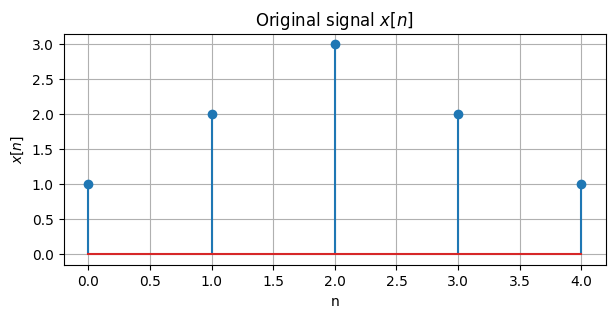

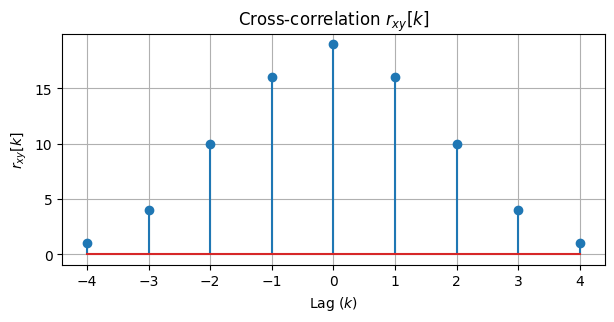

In [ ]:
import numpy as np

x = np.array([1, 2, 3, 2, 1])
y = np.array([1, 2, 3, 2, 1])

N = len(x)
M = len(y)
nx = np.arange(len(x))

r_xy = crosscorr(x, y)
lags = np.arange(-(N - 1), M)

stem_plot(n=nx, x=y,
    title="Original signal $x[n]$",
    xlabel="n",
    ylabel="$x[n]$"
)

stem_plot(n=lags, x=r_xy,
    title="Cross-correlation $r_{xy}[k]$",
    xlabel="Lag ($k$)",
    ylabel="$r_{xy}[k]$"
)

#El lag o valor de k donde se obtuvo el valor máximo fue cuando k=0, o no hubo desplazamiento de la señal, teniendo un valor de 19. Esto ocurre ya que se estaba
#calculando una autocorrelación, y al ser la misma señal comparada con la misma señal sin desplazamientos se obtiene el máximo en 0.
#La simetría obervada se debe a que es una autocorrelación, por lo que los valores obtenidos de un lado del eje vertical estarán relfejados en el otro lado.


### Ejercicio 2 —  Cross-correlation and time displacement
Consider:\
x[n] = {0, 1, 2, 3, 2, 1, 0}\
y[n] = {0, 0, 0, 1, 2, 3, 2, 1, 0}
* a) Plot both signals.
* b) Compute Rₓᵧ[k].
* c) Plot the cross-correlation.
* d) Determine the lag corresponding to its maximum.
* e) Explain what this lag tells you about the relative position of the signals.



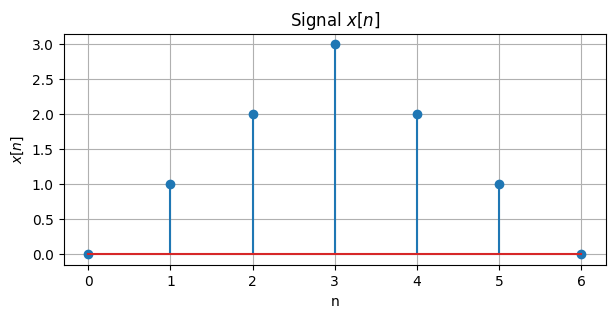

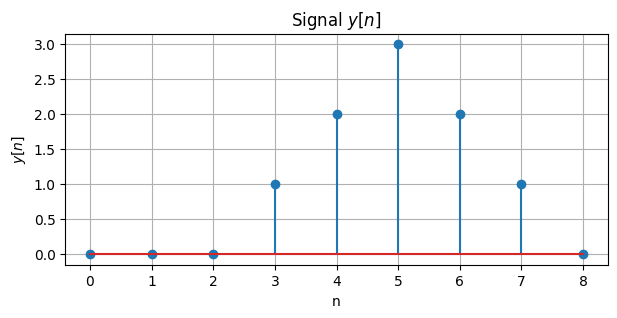

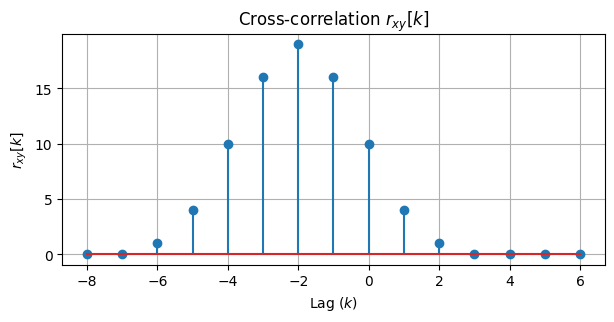

In [ ]:
x = np.array([0, 1, 2, 3, 2, 1, 0])
y = np.array([0, 0, 0, 1, 2, 3, 2, 1, 0])

N = len(x)
M = len(y)
nx = np.arange(len(x))
ny = np.arange(len(y))

r_xy = crosscorr(x, y)

lags = np.arange(-(M - 1), N)

stem_plot(n=nx, x=x,
    title="Signal $x[n]$",
    xlabel="n",
    ylabel="$x[n]$"
)

stem_plot(n=ny, x=y,
    title="Signal $y[n]$",
    xlabel="n",
    ylabel="$y[n]$"
)

stem_plot(n=lags, x=r_xy,
    title="Cross-correlation $r_{xy}[k]$",
    xlabel="Lag ($k$)",
    ylabel="$r_{xy}[k]$"
)
#El valor máximo de la correlación ocurre cuando k=-2, que es el valor que esta desplazada la señal y respecto de x.

#Una k=-2 indica que la señal esta desfasada en el tiempo respecto a la señal x[n] en 2 muestras. Por lo que para que el valor máximo esté en k=0 debemos
#mover a la señal x[n] en dos muestras hacia la izquierda.


### Ejercicio 3 - Detecting a known pattern
A receiver observes\
x[n] = {0, 0, 1, −1, 2, 1, −1, 0, 0}\
and searches for the pattern\
p[n] = {1, −1, 2, 1, −1}
* a) Compute the cross-correlation between x[n] and p[n].
* b) Plot the result.
* c) Determine where the pattern occurs in x[n].
* d) Explain why correlation can be used as a detection mechanism.

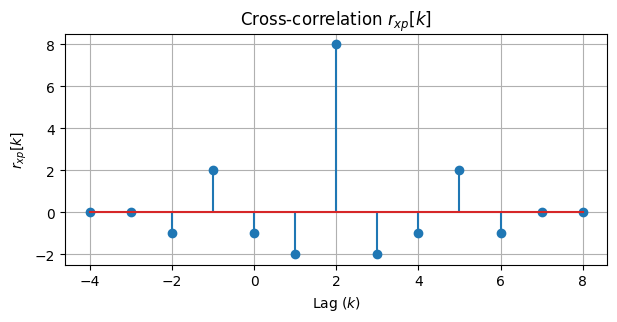

In [ ]:
x = np.array([0, 0, 1, -1, 2, 1, -1, 0, 0])
p = np.array([1, -1, 2, 1, -1])

N = len(x)
M = len(p)
nx = np.arange(len(x))
ny = np.arange(len(p))

r_xp = crosscorr(x, p)

lags = np.arange(-(M - 1), N)

stem_plot(n=lags, x=r_xp,
    title="Cross-correlation $r_{xp}[k]$",
    xlabel="Lag ($k$)",
    ylabel="$r_{xp}[k]$"
)

#Ocurre cuando k=2, esto nos indica que la señal de prueba se encuentra en la señal principal, con un desplazamiento de 2 muestras a la derecha.

#La correlación puede ser usada como un mecanismo de detección debido a que en esencia lo que hace es comparar una señal con la otra, contemplando también cada uno de
#los atrasos y adelantos, por lo que va recorriendo la señal muestra a muestra, y donde obtiene el mayor valor es donde la señal se parece o más posible a la original.


### Ejercicio 4 — Autocorrelation of a sinusoid
Generate\
x(t) = sin(2π·5t),     0 ≤ t ≤ 2 s,     fₛ = 100 Hz
* a) Plot the signal.
* b) Compute and plot its autocorrelation.
* c) Measure the distance, in samples, between consecutive autocorrelation maxima.
* d) Convert this distance into seconds.
* e) What relationship do you observe between this value and the frequency of the original signal?


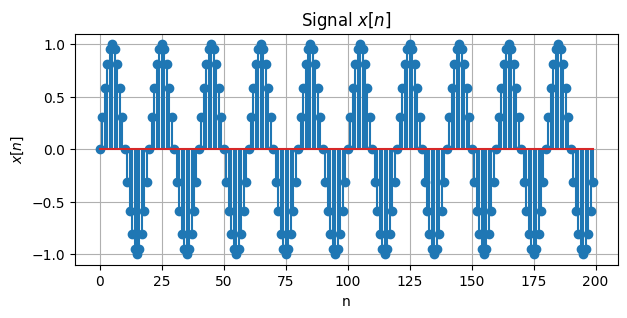

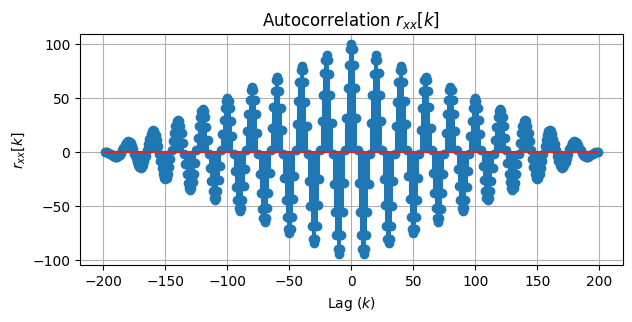

In [ ]:
f=5
f_s=100
T_s=1/f_s

N = 2*f_s
n_vector = np.arange(N)
x = senaltemporal_a_discreta(n_vector, f=5, f_s=100)
y = x
N = len(x)
M = len(y)
nx = np.arange(len(x))

r_xy=crosscorr(x, y)
lags = np.arange(-(M - 1), N)

stem_plot(n=nx, x=x,
    title="Signal $x[n]$",
    xlabel="n",
    ylabel="$x[n]$"
)

stem_plot(n=lags, x=r_xy,
    title="Autocorrelation $r_{xx}[k]$",
    xlabel="Lag ($k$)",
    ylabel="$r_{xx}[k]$"
)

#La distancia en muestras entre dos máximos es de 20 muestras.

#Para convertirlo a segundos aplicamos t=k*T_s=20*0.01=0.2 s

#La relación que se observa es que la distancia temporal entre dos máximos consecutivos es igual al periodo fundamental de la señal, la cual nos dice cuantas muestras podremos obtener
#de un solo periodo.


### Ejercicio 5 — Comparing signals with different frequencies
Generate\
x(t) = sin(2π·5t)\
r₁(t) = sin(2π·5t)     
r₂(t) = sin(2π·8t)
* a) Plot all three signals.
* b) Calculate the cross-correlation between x(t) and each reference.
* c) Compare the maximum absolute correlation obtained in each case.
* d) Which reference provides the strongest response? Explain why.



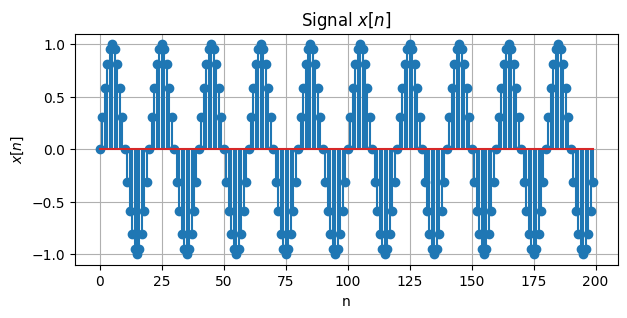

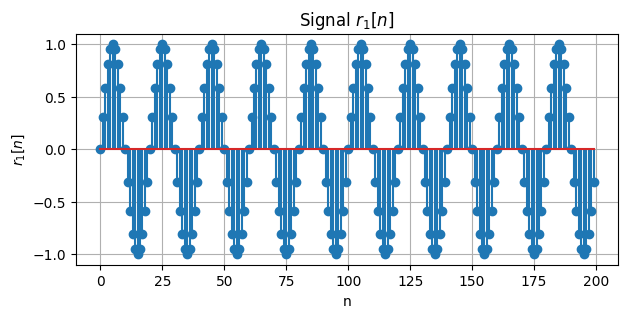

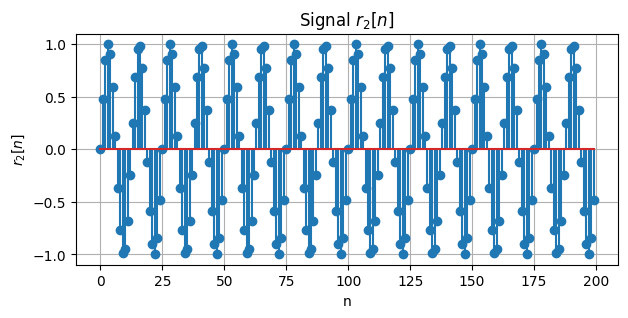

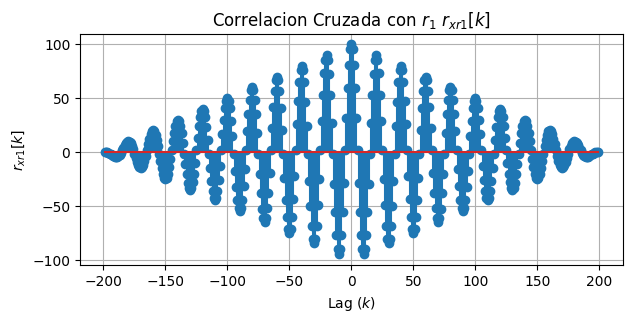

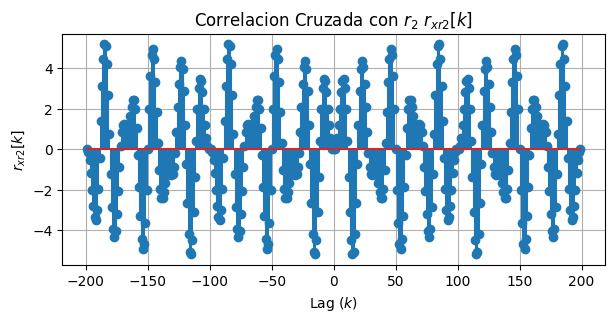

In [ ]:
f_s=100
T_s=1/f_s

N = 2*f_s
n_vector = np.arange(N)
x = senaltemporal_a_discreta(n_vector, f=5, f_s=100)
r_1 = senaltemporal_a_discreta(n_vector, f=5, f_s=100)
r_2 = senaltemporal_a_discreta(n_vector, f=8, f_s=100)

N = len(x)
M = len(r_1)
nx = np.arange(len(x))
nr_1 = np.arange(len(r_1))
nr_2 = np.arange(len(r_1))

r_xr1=crosscorr(x, r_1)
r_xr2=crosscorr(x, r_2)
lags = np.arange(-(M - 1), N)

stem_plot(n=nx, x=x,
    title="Signal $x[n]$",
    xlabel="n",
    ylabel="$x[n]$"
)

stem_plot(n=nr_1, x=r_1,
    title="Signal $r_1[n]$",
    xlabel="n",
    ylabel="$r_1[n]$"
)

stem_plot(n=nr_2, x=r_2,
    title="Signal $r_2[n]$",
    xlabel="n",
    ylabel="$r_2[n]$"
)

stem_plot(n=lags, x=r_xr1,
    title="Correlacion Cruzada con $r_1$ $r_{xr1}[k]$",
    xlabel="Lag ($k$)",
    ylabel="$r_{xr1}[k]$"
)

stem_plot(n=lags, x=r_xr2,
    title="Correlacion Cruzada con $r_2$ $r_{xr2}[k]$",
    xlabel="Lag ($k$)",
    ylabel="$r_{xr2}[k]$"
)

#Para el caso donde se hace la correlación entre la señal principal y la primer referencia se obtiene un valor máximo de 100, mientras que con la segunda referencia obtenemos un valor
#cercano a 5, la cual es mucho menor en comparación con la primera.

#La referencia que nos da una mayor respuesta es la primera, esto ya que su frecuencia es la misma que la de la señal original, por lo que se alinean en K=0.


### Ejercicio 6 — Finding a hidden frequency
The observed signal is\
x(t) = 2 sin(2π·7t)\
Assume its frequency is one of {3, 5, 7, 9, 11} Hz. For every candidate frequency f, generate\
r_f(t) = sin(2πft)
* a) Compute the correlation of x(t) with each reference signal.
* b) Store the maximum absolute correlation obtained for each frequency.
* c) Plot correlation magnitude versus candidate frequency.
* d) Determine the frequency present in x(t).



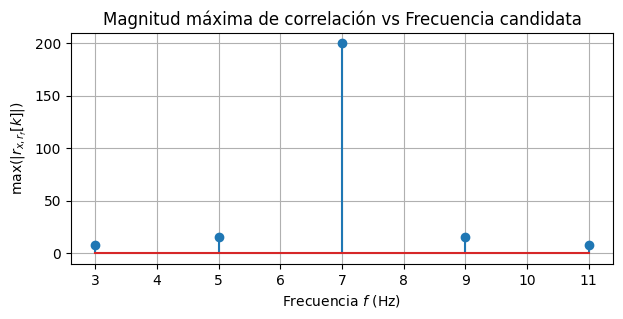

In [ ]:
f_s=100
T_s=1/f_s

N = 2*f_s
n_vector = np.arange(N)
x = 2* senaltemporal_a_discreta(n_vector, f=7, f_s=100)
r_1 = senaltemporal_a_discreta(n_vector, f=3, f_s=100)
r_2 = senaltemporal_a_discreta(n_vector, f=5, f_s=100)
r_3 = senaltemporal_a_discreta(n_vector, f=7, f_s=100)
r_4 = senaltemporal_a_discreta(n_vector, f=9, f_s=100)
r_5 = senaltemporal_a_discreta(n_vector, f=11, f_s=100)

N = len(x)
M = len(r_1)
nx = np.arange(len(x))

r_xr1=crosscorr(x, r_1)
r_xr2=crosscorr(x, r_2)
r_xr3=crosscorr(x, r_3)
r_xr4=crosscorr(x, r_4)
r_xr5=crosscorr(x, r_5)
lags = np.arange(-(M - 1), N)

max_val1 = np.max(np.abs(r_xr1))
max_val2 = np.max(np.abs(r_xr2))
max_val3 = np.max(np.abs(r_xr3))
max_val4 = np.max(np.abs(r_xr4))
max_val5 = np.max(np.abs(r_xr5))

frecuencias = [3, 5, 7, 9, 11]
maximos_correlacion = [max_val1, max_val2, max_val3, max_val4, max_val5]

stem_plot(
    n=frecuencias,
    x=maximos_correlacion,
    title="Magnitud máxima de correlación vs Frecuencia candidata",
    xlabel="Frecuencia $f$ (Hz)",
    ylabel=r"$\max(|r_{x, r_f}[k]|)$"
)

#La frecuencia presente es 7 Hz, ya que fue el que tuvo un valor mayor entre todas las frecuencias al hacer la correlación.


## Ejercicio 7- Detecting two frequencies
Consider\
x(t) = 2 sin(2π·5t) + 0.8 sin(2π·12t)\
Sample the signal at fₛ = 100 Hz for 2 seconds. Test candidate frequencies f = {2, 3, 4, …, 20} Hz using\
r_f(t) = sin(2πft)
* a) Plot x(t).
* b) Compute its correlation with every reference sinusoid.
* c) For each frequency, obtain a single measure representing the strength of the correlation.
* d) Plot correlation magnitude versus frequency.
* e) Identify the two dominant frequencies.
* f) Can the relative amplitudes of the two components be inferred from the correlation results? Explain.


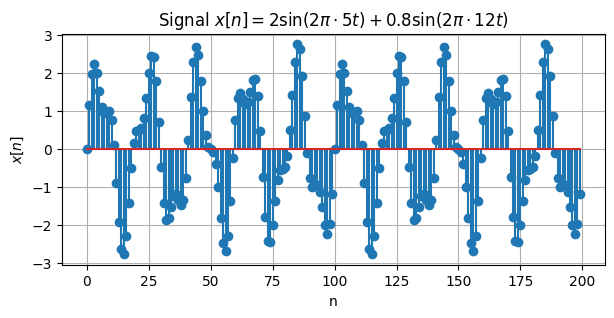

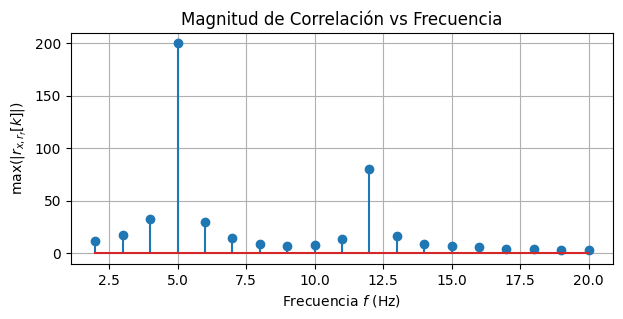

In [ ]:
f_s = 100
t_end = 2
n_vector = np.arange(int((2) * f_s))

x = 2 * np.sin(2 * np.pi * 5 * (n_vector / f_s)) + 0.8 * np.sin(2 * np.pi * 12 * (n_vector / f_s))

stem_plot(
    n=n_vector,
    x=x,
    title=r"Signal $x[n] = 2\sin(2\pi \cdot 5t) + 0.8\sin(2\pi \cdot 12t)$",
    xlabel="n",
    ylabel="$x[n]$"
)

frecuencias = np.arange(2, 21)
maximos_correlacion = []

for f in frecuencias:
    r_f = np.sin(2 * np.pi * f * (n_vector / f_s))
    r_x_rf = crosscorr(x, r_f)
    max_val = np.max(np.abs(r_x_rf))
    maximos_correlacion.append(max_val)

stem_plot(
    n=frecuencias,
    x=maximos_correlacion,
    title="Magnitud de Correlación vs Frecuencia",
    xlabel="Frecuencia $f$ (Hz)",
    ylabel=r"$\max(|r_{x, r_f}[k]|)$"
)

#Las dos frecuencias dominantes son 5 Hz y 12 Hz, que son las frecuencias de las dos funciones de la señal original.

#Sí, las amplitudes relativas se pueden inferir directamente de los valores de correlación, ya que la energía
#acumulada en el pico de correlación para una frecuencia coincidente es proporcional a la amplitud de esa componente en la señal original.
#Por lo tanto, la altura de los picos en la correlación preserva la proporción entre las amplitudes de los tonos presentes.


## Ejercicio 8 -  Phase and sinusoidal detection
Consider two signals with the same frequency but different phase:\
x₁(t) = sin(2π·8t)\
x₂(t) = sin(2π·8t + π/3)\
Initially use the sine reference
rₛ(t) = sin(2π·8t)
* a) Plot x₁(t), x₂(t), and rₛ(t).
* b) Compute the correlation between x₁(t) and rₛ(t).
* c) Compute the correlation between x₂(t) and rₛ(t).
* d) Compare the two results. Both signals have the same frequency. Why are their correlation values different?
* e) Now use the cosine reference r_c(t) = cos(2π·8t) and compute its correlation with x₁(t) and x₂(t).
* f) Considering the responses obtained using both sine and cosine references, explain why both are useful when the signal phase is unknown.

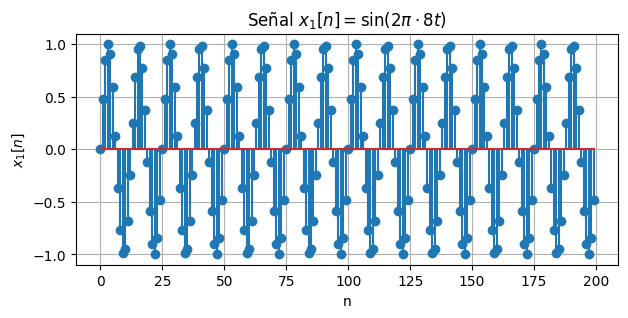

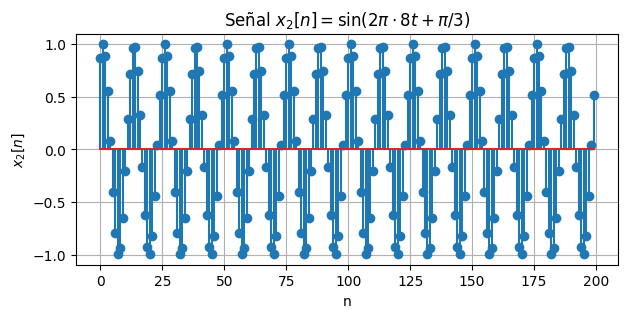

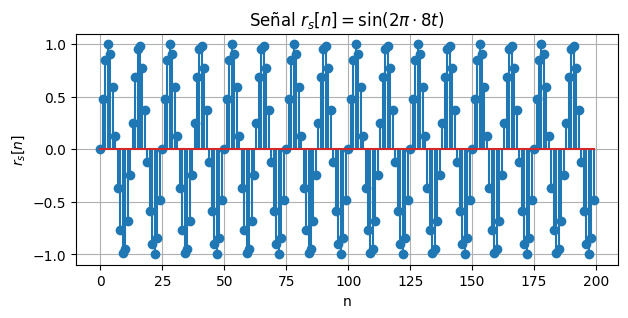

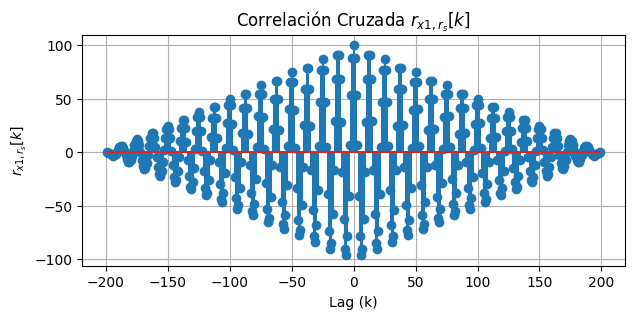

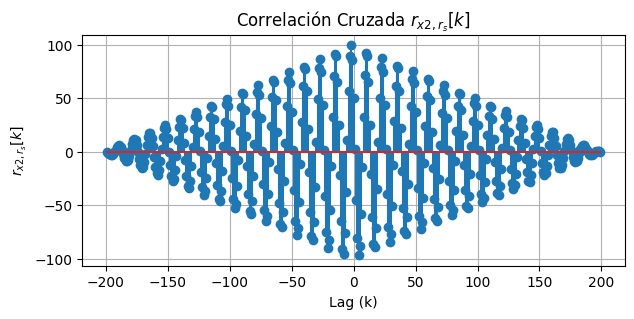

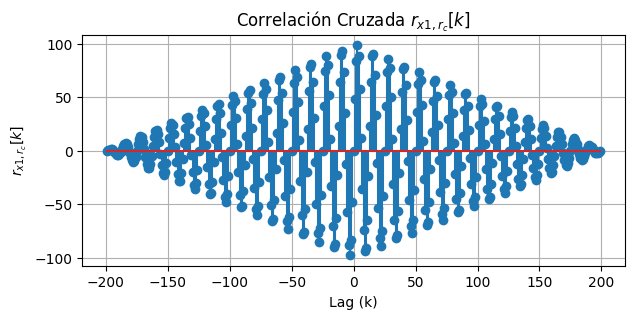

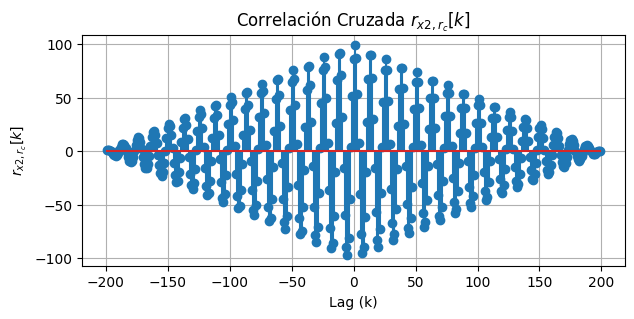

In [ ]:
f_s = 100
t_start, t_end = 0, 2
n_vector = np.arange(int((t_end - t_start) * f_s))

x1 = np.sin(2 * np.pi * 8 * (n_vector / f_s))
x2 = np.sin(2 * np.pi * 8 * (n_vector / f_s) + np.pi / 3)
r_s = np.sin(2 * np.pi * 8 * (n_vector / f_s))
r_c = np.cos(2 * np.pi * 8 * (n_vector / f_s))

N = len(x1)
M = len(r_s)
lags = np.arange(-(M - 1), N)

stem_plot(
    n=n_vector,
    x=x1,
    title=r"Señal $x_1[n] = \sin(2\pi \cdot 8t)$",
    xlabel="n",
    ylabel="$x_1[n]$"
)

stem_plot(
    n=n_vector,
    x=x2,
    title=r"Señal $x_2[n] = \sin(2\pi \cdot 8t + \pi/3)$",
    xlabel="n",
    ylabel="$x_2[n]$"
)

stem_plot(
    n=n_vector,
    x=x1,
    title=r"Señal $r_s[n] = \sin(2\pi \cdot 8t)$",
    xlabel="n",
    ylabel="$r_s[n]$"
)

r_x1_rs = crosscorr(x1, r_s)
r_x2_rs = crosscorr(x2, r_s)

stem_plot(
    n=lags,
    x=r_x1_rs,
    title=r"Correlación Cruzada $r_{x1, r_s}[k]$",
    xlabel="Lag (k)",
    ylabel=r"$r_{x1, r_s}[k]$"
)

stem_plot(
    n=lags,
    x=r_x2_rs,
    title=r"Correlación Cruzada $r_{x2, r_s}[k]$",
    xlabel="Lag (k)",
    ylabel=r"$r_{x2, r_s}[k]$"
)

r_x1_rc = crosscorr(x1, r_c)
r_x2_rc = crosscorr(x2, r_c)

stem_plot(
    n=lags,
    x=r_x1_rc,
    title=r"Correlación Cruzada $r_{x1, r_c}[k]$",
    xlabel="Lag (k)",
    ylabel=r"$r_{x1, r_c}[k]$"
)

stem_plot(
    n=lags,
    x=r_x2_rc,
    title=r"Correlación Cruzada $r_{x2, r_c}[k]$",
    xlabel="Lag (k)",
    ylabel=r"$r_{x2, r_c}[k]$"
)

#La magnitud alcanzada para ambos casos es la misma de 100, pero sus valores de correlación son diferentes ya que la posición del pico en una es diferente a la
#de la otra, y si comparamos el valor en el mismo instante de tiempo (K=0), se tiene una diferencia del 50%. Esto sucede ya que un cambio de fase no altera la energía
#ni la amplitud de la señal; simplemente la desplaza en el tiempo. La correlación cruzada encuentra la coincidencia perfecta de fase en un desplazamiento k distinto de cero.

#Usar tanto la función seno como la coseno son útiles ya que si solo usamos la del seno se pueden llegar a tener puntos ciegos si es que la señal llega desfasada 90°,
#en cambio, si usamos las dos referencias desfasadas entre sí podemos calcular la magnitud total, y debido a la propiedad de sen cuadrado + coseno cuadrado =1, nos dará
#la energía completa de la señal.



# Ejercicio 9 - Frequency detection in white Gaussian noise
Generate the sampled signal\
x[n] = sin(2π·6n/fₛ) + 0.7 sin(2π·15n/fₛ) + w[n]\
using fₛ = 100 Hz. Here w[n] denotes zero-mean white Gaussian noise: independent Gaussian samples with mean 0 and a selected standard deviation σ.
* a) Plot the clean signal and the noisy signal.
* b) Test reference frequencies from 1 to 20 Hz.
* c) Calculate the correlation response for every candidate frequency.
* d) Plot correlation magnitude versus frequency.
* e) Determine whether the frequencies 6 Hz and 15 Hz can still be detected.
* f) Repeat for at least three different values of σ and discuss what happens as the noise level increases.


<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2511/1898838264.py:45: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Magnitud de Correlación vs Frecuencia ($\sigma = {sigma}$)")


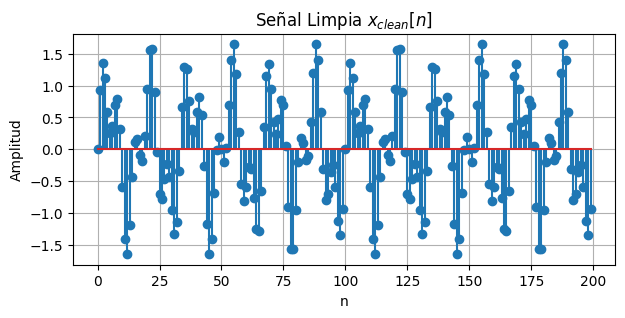

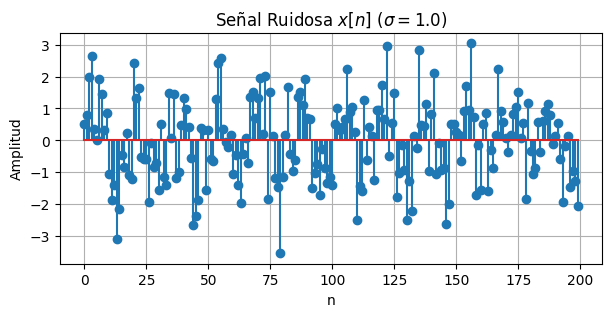

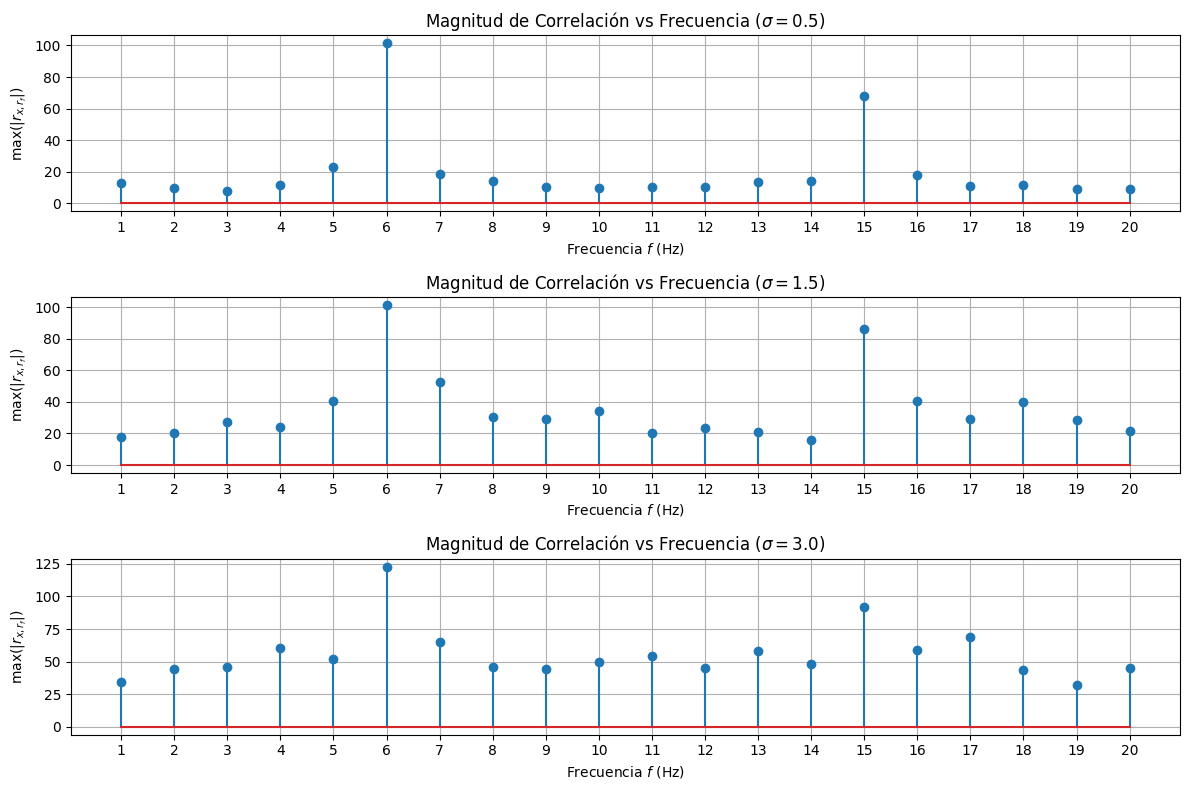

In [ ]:
f_s = 100
n_vector = np.arange(int(2 * f_s))

x_clean = np.sin(2 * np.pi * 6 * (n_vector / f_s)) + 0.7 * np.sin(2 * np.pi * 15 * (n_vector / f_s))

frecuencias = np.arange(1, 21)

sigmas = [0.5, 1.5, 3.0]

np.random.seed(42)
w = np.random.normal(0, 1.0, len(n_vector))
x_noisy = x_clean + w

stem_plot(
    n=n_vector,
    x=x_clean,
    title=r"Señal Limpia $x_{clean}[n]$",
    xlabel="n",
    ylabel="Amplitud"
)

stem_plot(
    n=n_vector,
    x=x_noisy,
    title=r"Señal Ruidosa $x[n]$ ($\sigma = 1.0$)",
    xlabel="n",
    ylabel="Amplitud"
)

plt.figure(figsize=(12, 8))

for idx, sigma in enumerate(sigmas):
    w = np.random.normal(0, sigma, len(n_vector))
    x_noisy = x_clean + w

    maximos_correlacion = []

    for f in frecuencias:
        r_f = np.sin(2 * np.pi * f * (n_vector / f_s))
        r_x_rf = crosscorr(x_noisy, r_f)
        maximos_correlacion.append(np.max(np.abs(r_x_rf)))

    plt.subplot(len(sigmas), 1, idx + 1)
    plt.stem(frecuencias, maximos_correlacion)
    plt.title(f"Magnitud de Correlación vs Frecuencia ($\sigma = {sigma}$)")
    plt.xlabel("Frecuencia $f$ (Hz)")
    plt.ylabel(r"$\max(|r_{x, r_f}|)$")
    plt.xticks(frecuencias)
    plt.grid(True)

plt.tight_layout()
plt.show()

#Las frecuencias de 6 Hz y 15 Hz siguen siendo visibles en la grafica a pesar de existir ruido en la señal.

#Conforme la señal se va volviendo mas ruidosa, el piso de ruido de correlacion va aumentando, lo que provoca que la señal de 15 Hz se comience a perder
#entre las demas frecuencias.

# Ejercicio 10 - Build a frequency detector
Design a Python function:\
detect_frequencies(x, fs, frequencies)\
The function must receive a sampled signal x, sampling frequency fs, and a list of candidate frequencies, and return a measure of the presence of every candidate frequency.
Test it using
x(t) = 1.5 sin(2π·4t) + 0.7 sin(2π·9t + π/4) + 2 sin(2π·16t − π/3)
* a) Search frequencies from 1 to 20 Hz.
* b) Plot the original signal.
* c) Plot detector response versus frequency.
* d) Identify the three dominant frequencies.
* e) Rank them according to their detected strength.
* f) Explain why a detector using both sine and cosine references is preferable to one using only sine.


/tmp/ipykernel_4046/1715994928.py:35: RuntimeWarning: invalid value encountered in sqrt
  magnitud = (2.0 / N) * np.sqrt(proy_cos*2 + proy_sin*2)


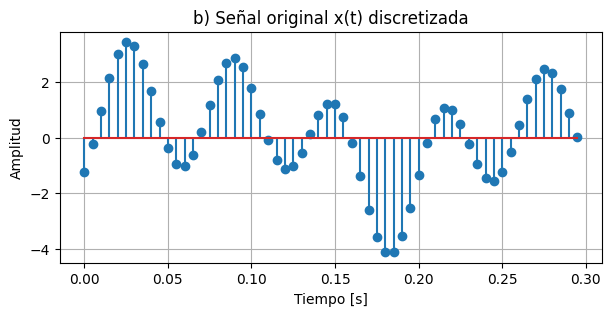

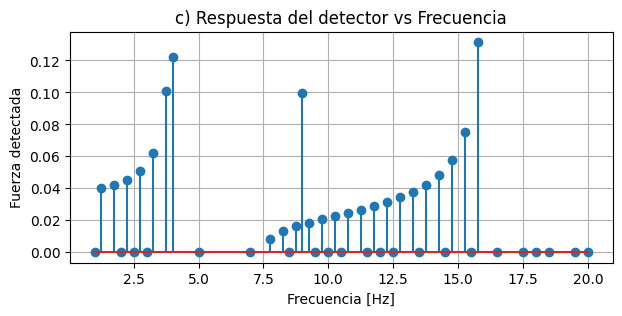

d) y e) Tres frecuencias dominantes ordenadas por intensidad:


In [ ]:
fs = 200
duracion = 2.0
N = int(fs * duracion)
n = np.arange(N)
t = n / fs

x = (1.5 * np.sin(2 * np.pi * 4 * t) +
     0.7 * np.sin(2 * np.pi * 9 * t + np.pi/4) +
     2.0 * np.sin(2 * np.pi * 16 * t - np.pi/3))

frecuencias = np.linspace(1, 20, 77)

respuestas = detect_frequencies(x, fs, frecuencias)

stem_plot(
    n=t[:60],
    x=x[:60],
    title="b) Señal original x(t) discretizada",
    xlabel="Tiempo [s]",
    ylabel="Amplitud"
)

stem_plot(
    n=frecuencias,
    x=respuestas,
    title="c) Respuesta del detector vs Frecuencia",
    xlabel="Frecuencia [Hz]",
    ylabel="Fuerza detectada"
)

picos = []
for i in range(1, len(respuestas) - 1):
    if respuestas[i] > respuestas[i - 1] and respuestas[i] > respuestas[i + 1] and respuestas[i] > 0.2:
        picos.append(i)

picos_ordenados = sorted(picos, key=lambda idx: respuestas[idx], reverse=True)[:3]

print("d) y e) Tres frecuencias dominantes ordenadas por intensidad:")
for rank, idx in enumerate(picos_ordenados, 1):
    print(f"  {rank}° lugar: {frecuencias[idx]:.1f} Hz (Amplitud detectada ≈ {respuestas[idx]:.2f})")

#Un detector que utiliza tanto el seno como el coseno (detección en cuadratura) es preferible porque elimina los puntos ciegos causados por el desfase de la señal,
#permitiendo medir la amplitud total de forma constante y conocer la fase exacta del desfase. Además, a diferencia de usar solo el seno, este enfoque permite
#diferenciar si la frecuencia de la señal recibida está por encima o por debajo de la frecuencia de referencia.


## Checklist antes de entregar

- [ ] Tu nombre/matrícula/grupo están completos  
- [ ] Todas las celdas corren sin error  
- [ ] Hay gráficas claras para cada ejercicio  
- [ ] No usaste funciones prohibidas  
- [ ] Incluiste la sección de IA (3 ejercicios mínimo)
